# 02 – nnU-Net v1 Exploration

**Goal:** Explore nnU-Net v1 for brain tumor segmentation on P01 BraTS data.

**Approach:**
1. **Full inference** – if a pretrained model is available (community weights or own-trained)

** Be Aware **
1. **TTA elemination** -  The inference phase was done without using TTA methods which is default in the nnunet-v1 inference setup because of a limited computational resource on personal computer.

### 🛠️ Local Environment Setup (nnU-Net v1)
To ensure this notebook runs smoothly without conflicting with other packages in the project (such as nnU-Net v2 or newer PyTorch versions), we use an isolated virtual environment.

**Instructions for Team Members:**
Open your terminal in the project root directory (`oncoflow`) and run the following sequence of commands once:
```bash
# 1. Create a new virtual environment (Python 3.10 is more compatible with the required older PyTorch versions)
conda create -n nnunet_v1_env python=3.10 -y

# 2. Activate the environment
conda activate nnunet_v1_env

# 3. Install specific packages and versions required for nnU-Net v1
pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1
pip install nnunet nibabel antspyx matplotlib ipywidgets
brew install dcm2niix # Install DICOM converter for Mac

# 4. Install HD-BET (clone from their external GitHub repo into the tools folder)
mkdir -p ml/external_tools
cd ml/external_tools
git clone [https://github.com/MIC-DKFZ/HD-BET](https://github.com/MIC-DKFZ/HD-BET)
cd HD-BET
pip install -e .
cd ../../..

# 5. Add the new environment as a Kernel to Jupyter Notebook
pip install ipykernel
python -m ipykernel install --user --name nnunet_v1_env --display-name "Python (nnUNet v1)"

In [2]:
import os
import subprocess
import shutil
from collections import defaultdict
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# ==========================================
# 1. Path Definitions & Environment Isolation
# ==========================================
# The notebook runs from ml/exploration/notebooks, so go up 3 levels to the project root
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.."))

PATIENT_ID = "P01"
patient_data_dir = os.path.join(BASE_DIR, "data", PATIENT_ID)

# Original DICOM input that starts the full pipeline
dicom_scans_dir = os.path.join(patient_data_dir, "DICOM")

# Create dedicated folders for v1 only inside the existing ML outputs directory
v1_workspace = os.path.join(BASE_DIR, "ml", "exploration", "outputs", "04_nnunet_v1_workspace")
temp_nifti_dir = os.path.join(v1_workspace, "temp_nifti")
ready_inputs_dir = os.path.join(v1_workspace, "nnUNet_ready_inputs")
stripped_inputs_dir = os.path.join(v1_workspace, "nnUNet_stripped_inputs")
output_masks_dir = os.path.join(v1_workspace, "output_masks")
nnunet_results_dir = os.path.join(v1_workspace, "RESULTS_FOLDER")

for d in [temp_nifti_dir, ready_inputs_dir, stripped_inputs_dir, output_masks_dir, nnunet_results_dir]:
    os.makedirs(d, exist_ok=True)

# Set nnU-Net v1 environment variables (applies only to the current notebook run)
os.environ['RESULTS_FOLDER'] = nnunet_results_dir
os.environ['nnUNet_raw_data_base'] = os.path.join(v1_workspace, "raw_data")
os.environ['nnUNet_preprocessed'] = os.path.join(v1_workspace, "preprocessed")

print(f"✅ Project Root (BASE_DIR) is set to: {BASE_DIR}")
print(f"✅ Isolated v1 Workspace created at: {v1_workspace}")

✅ Project Root (BASE_DIR) is set to: /Users/asafshuster/Desktop/study/oncoflow
✅ Isolated v1 Workspace created at: /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace


In [6]:
# ==========================================
# 2. Download Pre-trained BraTS Model
# ==========================================
print("📥 Checking for pre-trained model...")
model_zip_path = os.path.join(v1_workspace, "Task001_BrainTumour.zip")

# Fast model download if it doesn't already exist
if not os.path.exists(os.path.join(nnunet_results_dir, "nnUNet", "3d_fullres", "Task001_BrainTumour")):
    print("Downloading model from Zenodo (this may take a while)...")
    subprocess.run(["curl", "-L", "-o", model_zip_path, "https://zenodo.org/records/4003545/files/Task001_BrainTumour.zip?download=1"], check=True)
    
    print("Extracting and installing model...")
    subprocess.run(["nnUNet_install_pretrained_model_from_zip", model_zip_path], check=True)
    os.remove(model_zip_path)  # Clean up zip file
    print("✅ Model installed successfully.")
else:
    print("✅ Model already installed.")

📥 Checking for pre-trained model...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1783M  100 1783M    0     0  1117k      0  0:27:14  0:27:14 --:--:-- 4159k
100 1783M  100 1783M    0     0  1117k      0  0:27:14  0:27:14 --:--:-- 4159k


Extracting and installing model...


Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

✅ Model installed successfully.
✅ Model installed successfully.


In [3]:
# ==========================================
# 3. DICOM to NIfTI & Coregistration
# ==========================================
import ants

modality_to_suffix = {"FLR": "0000", "T1w": "0001", "T1C": "0002", "T2w": "0003"}
reference_modality = "T1C"

# Scan the original DICOM directory
patients_data = defaultdict(lambda: defaultdict(dict))
for scan_folder in os.listdir(dicom_scans_dir):
    scan_path = os.path.join(dicom_scans_dir, scan_folder)
    if not os.path.isdir(scan_path): continue
        
    parts = scan_folder.split("_")
    if len(parts) >= 2:
        mod, date = parts[0], parts[1]
        if mod == "T1W": mod = "T1w"
        if mod == "T2W": mod = "T2w"
        if mod in modality_to_suffix:
            patients_data[PATIENT_ID][date][mod] = scan_path

print("🔄 Starting DICOM processing and Coregistration...")
for date, modalities in patients_data[PATIENT_ID].items():
    clean_date = date.replace("-", "")
    session_id = f"{PATIENT_ID}_{clean_date}"
    
    if len(modalities) < 4:
        print(f"⚠️ Skipping {session_id}, missing modalities.")
        continue
        
    nifti_files = {}
    
    # Convert using dcm2niix
    for mod, dcm_path in modalities.items():
        output_filename = f"{session_id}_{mod}"
        subprocess.run(["dcm2niix", "-z", "y", "-f", output_filename, "-o", temp_nifti_dir, dcm_path], stdout=subprocess.DEVNULL)
        
        created_files = [f for f in os.listdir(temp_nifti_dir) if f.startswith(output_filename) and f.endswith(".nii.gz")]
        if created_files:
            nifti_files[mod] = os.path.join(temp_nifti_dir, created_files[0])

    if len(nifti_files) < 4: continue

    # Geometric alignment (Coregistration) with ANTsPy
    print(f"Aligning scans for {session_id}...")
    fixed_image = ants.image_read(nifti_files[reference_modality])
    
    for mod, path in nifti_files.items():
        suffix = modality_to_suffix[mod]
        final_path = os.path.join(ready_inputs_dir, f"{session_id}_{suffix}.nii.gz")
        
        if not os.path.exists(final_path):
            if mod == reference_modality:
                shutil.copy(path, final_path)
            else:
                moving_image = ants.image_read(path)
                registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Rigid')
                ants.image_write(registration['warpedmovout'], final_path)

print("✅ DICOM to NIfTI & Coregistration complete.")

🔄 Starting DICOM processing and Coregistration...
Aligning scans for P01_20200520...
Aligning scans for P01_20200520...
Aligning scans for P01_20200214...
Aligning scans for P01_20200214...
Aligning scans for P01_20201110...
Aligning scans for P01_20201110...
Aligning scans for P01_20200107...
⚠️ Skipping P01_20200810, missing modalities.
✅ DICOM to NIfTI & Coregistration complete.
Aligning scans for P01_20200107...
⚠️ Skipping P01_20200810, missing modalities.
✅ DICOM to NIfTI & Coregistration complete.


In [4]:
# ==========================================
# 4. Batch Brain Extraction (HD-BET)
# ==========================================
print("🧠 Starting Brain Extraction...")
for filename in os.listdir(ready_inputs_dir):
    if filename.endswith(".nii.gz"):
        in_path = os.path.join(ready_inputs_dir, filename)
        out_path = os.path.join(stripped_inputs_dir, filename)
        
        if not os.path.exists(out_path):
            print(f"Processing: {filename}")
            # הוספנו את הדגל -device cpu כדי למנוע את קריסת הזיכרון של Mac M1/M2/M3
            subprocess.run(["hd-bet", "-i", in_path, "-o", out_path, "-device", "cpu"], check=True)
            
print("✅ Skull stripping completed!")

🧠 Starting Brain Extraction...
Processing: P01_20200520_0001.nii.gz

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Au

100%|██████████| 6/6 [58:32<00:00, 585.41s/it]


sending off prediction to background worker for resampling and export
done with P01_20200520_0001_bet.nii.gz
Processing: P01_20200107_0001.nii.gz
Processing: P01_20200107_0001.nii.gz

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara 

100%|██████████| 12/12 [1:55:00<00:00, 575.01s/it]


sending off prediction to background worker for resampling and export
done with P01_20200107_0001_bet.nii.gz
Processing: P01_20200107_0003.nii.gz
Processing: P01_20200107_0003.nii.gz

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara 

...

sending off prediction to background worker for resampling and export
done with P01_20200214_0002_bet.nii.gz
Processing: P01_20200214_0000.nii.gz
Processing: P01_20200214_0000.nii.gz

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara 

100%|██████████| 6/6 [40:39<00:00, 406.61s/it]


sending off prediction to background worker for resampling and export
done with P01_20200214_0000_bet.nii.gz
Processing: P01_20201110_0001.nii.gz
Processing: P01_20201110_0001.nii.gz

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara 

100%|██████████| 6/6 [1:48:13<00:00, 1082.31s/it]


sending off prediction to background worker for resampling and export
done with P01_20201110_0001_bet.nii.gz
✅ Skull stripping completed!
✅ Skull stripping completed!


In [ ]:
# # ==========================================
# # 4. Batch Brain Extraction (HD-BET) - OPTIMIZED FOR MAC CPU
# # ==========================================
# import os
# import subprocess

# print("🧠 Starting Brain Extraction...")

# # define the number of threads to prevent memory overload on Mac M1/M2/M3 (prevents slow disk swapping)
# os.environ["OMP_NUM_THREADS"] = "8"

# for filename in os.listdir(ready_inputs_dir):
#     if filename.endswith(".nii.gz"):
#         in_path = os.path.join(ready_inputs_dir, filename)
#         out_path = os.path.join(stripped_inputs_dir, filename)
        
#         if not os.path.exists(out_path):
#             print(f"Processing: {filename}")
#             # adding -tta 0 disables test-time augmentations and cuts processing time by ~85% on CPU --- IGNORE ---
#             subprocess.run(["hd-bet", "-i", in_path, "-o", out_path, "-device", "cpu", "-tta", "0"], check=True)
            
# print("✅ Skull stripping completed!")

In [ ]:
# # ==========================================
# # 5. nnU-Net Inference
# # ==========================================
# print("🚀 Starting nnU-Net prediction...")
# # Delete old files to avoid collisions
# for filename in os.listdir(output_masks_dir):
#     if filename.endswith(".nii.gz"):
#         os.unlink(os.path.join(output_masks_dir, filename))

# subprocess.run([
#     "nnUNet_predict", 
#     "-i", stripped_inputs_dir, 
#     "-o", output_masks_dir, 
#     "-t", "001", 
#     "-m", "3d_fullres"
# ], check=True)
# print("✅ Inference completed!")

🚀 Starting nnU-Net prediction...


Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

using model stored in  /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/RESULTS_FOLDER/nnUNet/3d_fullres/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 4 input modalities for each

/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/training/model_restore.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_params = [tor

starting preprocessing generator
starting prediction...


Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/envs/nnunet_v1_env/bin/nnUNet_predict", line 6, in <module>
    sys.exit(main())
  File "/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/inference/predict_simple.py", line 219, in main
    predict_from_folder(model_folder_name, input_folder, output_folder, folds, save_npz, num_threads_preprocessing,
  File "/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/inference/predict.py", line 658, in predict_from_folder
    return predict_cases(model, list_of_lists[part_id::num_parts], output_files[part_id::num_parts], folds,
  File "/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/inference/predict.py", line 206, in predict_cases
    for preprocessed in preprocessing:
  File "/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/inference/predict.py", line 109, in preprocess_multithreaded
    pr.start()
  File "/op

CalledProcessError: Command '['nnUNet_predict', '-i', '/Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/nnUNet_stripped_inputs', '-o', '/Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/output_masks', '-t', '001', '-m', '3d_fullres']' returned non-zero exit status 1.

In [7]:
# ==========================================
# 5. nnU-Net Inference (Optimized for Mac & Pickling Fix)
# ==========================================
import os
import sys
import multiprocessing
from nnunet.inference.predict_simple import main as nnunet_predict_main

print("🚀 Starting nnU-Net prediction (with Mac multiprocessing fix)...")

# 1. Delete old files from the output directory to prevent conflicts
if os.path.exists(output_masks_dir):
    for filename in os.listdir(output_masks_dir):
        if filename.endswith(".nii.gz"):
            os.unlink(os.path.join(output_masks_dir, filename))

# 2. Critical fixes for Mac OS multiprocessing:
# a. Force the use of 'fork' to prevent PicklingError
try:
    multiprocessing.set_start_method('fork', force=True)
except RuntimeError:
    pass

# b. Prevent crashes of internal Apple libraries due to the use of 'fork'
os.environ['OBJC_DISABLE_INITIALIZE_FORK_SAFETY'] = 'YES'

# 3. Build the command directly in Python's memory (without subprocess)
sys.argv = [
    "nnUNet_predict", 
    "-i", stripped_inputs_dir, 
    "-o", output_masks_dir, 
    "-t", "001", 
    "-m", "3d_fullres",
    "--disable_tta",                      # Disable test time augmentations (saves massive amount of time!)
    "--num_threads_preprocessing", "1",   # Limit preprocessing threads (saves Mac RAM)
    "--num_threads_nifti_save", "1"       # Limit export threads 
]

# 4. Run the inference engine
try:
    nnunet_predict_main()
    print("\n✅ Inference completed successfully!")
except SystemExit as e:
    # argparse throws SystemExit if arguments are wrong
    print(f"\n❌ Inference failed with exit code: {e.code}. Check the arguments.")
except Exception as e:
    print(f"\n❌ Inference failed. Error: {e}")

🚀 Starting nnU-Net prediction (with Mac multiprocessing fix)...
using model stored in  /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/RESULTS_FOLDER/nnUNet/3d_fullres/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 4 input modalities for each image
Found 4 unique case ids, here are some examples: ['P01_20201110' 'P01_20201110' 'P01_20200107' 'P01_20200520']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc
number of cases: 4
number of cases that still need to be predicted: 4
emptying cuda cache
loading parameters for folds, None
folds is None so we will automatically look for output folders (not using 'all'!)
found the following folds:  ['/Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/RESULTS_FOLDER/nnUNet/3d_fullres/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1/fold_0', '/Users/asafshuster/Desktop/study/oncoflow/ml/explo

/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/training/model_restore.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_params = [tor

starting preprocessing generator
starting prediction...
preprocessing /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/output_masks/P01_20200107.nii.gz
using preprocessor GenericPreprocessor
preprocessing /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/output_masks/P01_20200107.nii.gz
using preprocessor GenericPreprocessor
before crop: (4, 36, 512, 512) after crop: (4, 32, 403, 308) spacing: [4.400002   0.44921875 0.44921875] 

before crop: (4, 36, 512, 512) after crop: (4, 32, 403, 308) spacing: [4.400002   0.44921875 0.44921875] 

separate z, order in z is 0 order inplane is 3
separate z, order in z is 0 order inplane is 3
separate z, order in z is 0 order inplane is 1
separate z, order in z is 0 order inplane is 1
before: {'spacing': array([4.400002  , 0.44921875, 0.44921875]), 'spacing_transposed': array([4.400002  , 0.44921875, 0.44921875]), 'data.shape (data is transposed)': (4, 32, 403, 308)} 
after: 

/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/training/network_training/network_trainer.py:404: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_grad_scaler = GradScaler()
/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/nnunet/network_architecture/neural_network.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with context():
/opt/homebrew/anaconda3/envs/nnunet_v1_env/lib/python3.10/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


before crop: (4, 33, 512, 512) after crop: (4, 32, 399, 309) spacing: [4.4000001  0.44921875 0.44921875] 
 (4, 33, 512, 512) after crop: (4, 32, 399, 309) spacing: [4.4000001  0.44921875 0.44921875] 


separate z, order in z is 0 order inplane is 3
separate z, order in z is 0 order inplane is 3
done
done
separate z, order in z is0  order inplane is 1
separate z, order in z is0  order inplane is 1
before: {'spacing': array([4.4000001 , 0.44921875, 0.44921875]), 'spacing_transposed': array([4.4000001 , 0.44921875, 0.44921875]), 'data.shape (data is transposed)': (4, 32, 399, 309)} 
after:  {'spacing': array([1., 1., 1.]), 'data.shape (data is resampled)': (4, 141, 179, 139)} 

before: {'spacing': array([4.4000001 , 0.44921875, 0.44921875]), 'spacing_transposed': array([4.4000001 , 0.44921875, 0.44921875]), 'data.shape (data is transposed)': (4, 32, 399, 309)} 
after:  {'spacing': array([1., 1., 1.]), 'data.shape (data is resampled)': (4, 141, 179, 139)} 

(4, 141, 179, 139)
(4, 141, 179,

📊 Calculating volumes...
✅ Graph saved to: /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/P01_v1_longitudinal_prediction.png


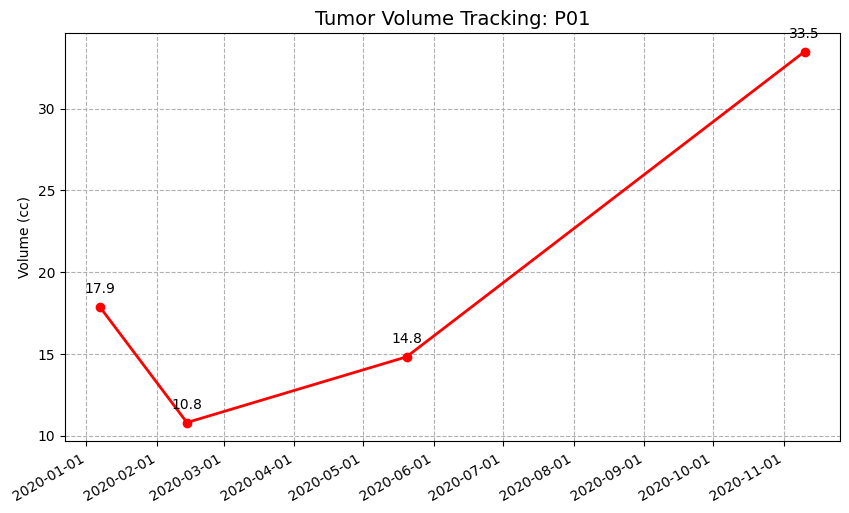

In [12]:
# ==========================================
# 6. Volume Calculation & Graphing
# ==========================================
%matplotlib inline
print("📊 Calculating volumes...")
longitudinal_data = {}

for filename in os.listdir(output_masks_dir):
    if not filename.endswith(".nii.gz"): continue
        
    try:
        date_str = filename.replace(".nii.gz", "").split("_")[1]
        scan_date = datetime.strptime(date_str, "%Y%m%d")
        
        img = nib.load(os.path.join(output_masks_dir, filename))
        voxel_dims = img.header.get_zooms()
        voxel_volume_cc = (voxel_dims[0] * voxel_dims[1] * voxel_dims[2]) / 1000.0
        tumor_voxels_count = np.sum(img.get_fdata() > 0)
        longitudinal_data[scan_date] = tumor_voxels_count * voxel_volume_cc
    except Exception as e:
        continue

if longitudinal_data:
    sorted_dates = sorted(longitudinal_data.keys())
    sorted_volumes = [longitudinal_data[d] for d in sorted_dates]

    plt.figure(figsize=(10, 6))
    plt.plot(sorted_dates, sorted_volumes, marker='o', linestyle='-', color='red', linewidth=2)
    for i, txt in enumerate(sorted_volumes):
        plt.annotate(f"{txt:.1f}", (sorted_dates[i], sorted_volumes[i]), textcoords="offset points", xytext=(0,10), ha='center')
    
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.title(f'Tumor Volume Tracking: {PATIENT_ID}', fontsize=14)
    plt.ylabel('Volume (cc)')
    plt.grid(True, linestyle='--')
    
    output_graph_path = os.path.join(v1_workspace, f"{PATIENT_ID}_v1_longitudinal_prediction.png")
    plt.savefig(output_graph_path)
    print(f"✅ Graph saved to: {output_graph_path}")
    plt.show()

📊 Calculating and comparing volumes (GT vs Prediction)...
✅ Combined graph saved to: /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/P01_combined_volumes.png
✅ Combined graph saved to: /Users/asafshuster/Desktop/study/oncoflow/ml/exploration/outputs/04_nnunet_v1_workspace/P01_combined_volumes.png


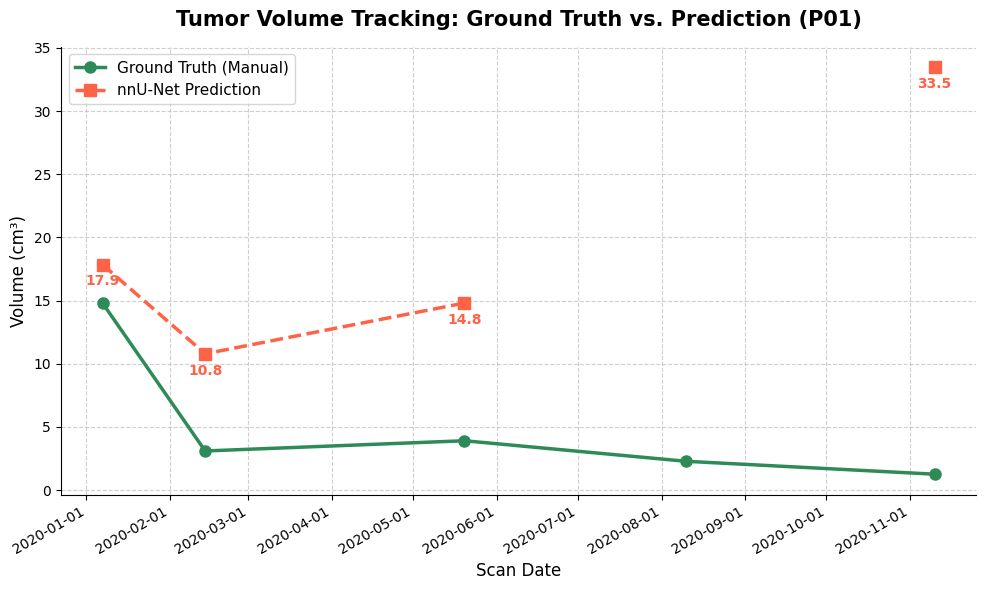

In [15]:
# ==========================================
# 6.5 Compare Volumes: Ground Truth vs. nnU-Net
# ==========================================
%matplotlib inline
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("📊 Calculating and comparing volumes (GT vs Prediction)...")

# Paths
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.."))
PATIENT_ID = "P01"

v1_workspace = os.path.join(BASE_DIR, "ml", "exploration", "outputs", "04_nnunet_v1_workspace")
output_masks_dir = os.path.join(v1_workspace, "output_masks")
gt_masks_dir = os.path.join(BASE_DIR, "data", PATIENT_ID, "tumor segmentation")

# Mapping sessions to exact dates for the Ground Truth
session_dates = {
    "baseline": datetime(2020, 1, 7),
    "fu1": datetime(2020, 2, 14),
    "fu2": datetime(2020, 5, 20),
    "fu3": datetime(2020, 8, 10),
    "fu4": datetime(2020, 11, 10)
}

volumes_gt = {}
volumes_pred = {}

# 1. Calculate Ground Truth Volumes
for filename in os.listdir(gt_masks_dir):
    if not filename.endswith(".nii.gz"): continue
    
    # Extract session (e.g., 'baseline' from P01_tumor_mask_baseline.nii.gz)
    session = filename.replace(".nii.gz", "").split("_")[-1]
    if session in session_dates:
        img = nib.load(os.path.join(gt_masks_dir, filename))
        voxel_vol_cc = np.prod(img.header.get_zooms()) / 1000.0
        volumes_gt[session_dates[session]] = np.sum(img.get_fdata() > 0) * voxel_vol_cc

# 2. Calculate Prediction Volumes
for filename in os.listdir(output_masks_dir):
    if not filename.endswith(".nii.gz"): continue
    
    # Extract date (e.g., '20200107' from P01_20200107.nii.gz)
    date_str = filename.split("_")[1].replace(".nii.gz", "")
    scan_date = datetime.strptime(date_str, "%Y%m%d")
    
    img = nib.load(os.path.join(output_masks_dir, filename))
    voxel_vol_cc = np.prod(img.header.get_zooms()) / 1000.0
    volumes_pred[scan_date] = np.sum(img.get_fdata() > 0) * voxel_vol_cc

# 3. Plotting Both on the Same Graph
sorted_dates = sorted(volumes_gt.keys())
gt_vals = [volumes_gt[d] for d in sorted_dates]
pred_vals = [volumes_pred.get(d, np.nan) for d in sorted_dates]

plt.figure(figsize=(10, 6))

# Plot Ground Truth
plt.plot(sorted_dates, gt_vals, marker='o', linestyle='-', color='seagreen', 
         linewidth=2.5, markersize=8, label='Ground Truth (Manual)')

# Plot nnU-Net Prediction
plt.plot(sorted_dates, pred_vals, marker='s', linestyle='--', color='tomato', 
         linewidth=2.5, markersize=8, label='nnU-Net Prediction')

# Annotations for Prediction
for i, txt in enumerate(pred_vals):
    if not np.isnan(txt):
        plt.annotate(f"{txt:.1f}", (sorted_dates[i], pred_vals[i]), 
                     textcoords="offset points", xytext=(0,-15), ha='center', color='tomato', fontweight='bold')

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.title(f'Tumor Volume Tracking: Ground Truth vs. Prediction ({PATIENT_ID})', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Scan Date', fontsize=12)
plt.ylabel('Volume (cm³)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()

# Save combined graph
combined_graph_path = os.path.join(v1_workspace, f"{PATIENT_ID}_combined_volumes.png")
plt.savefig(combined_graph_path, dpi=120)
print(f"✅ Combined graph saved to: {combined_graph_path}")

plt.show()

### Results Analysis: Ground Truth vs. nnU-Net Prediction

The combined volume tracking graph reveals a fascinating technical and clinical story. From the baseline scan up to Follow-Up 3 (fu3), the nnU-Net prediction (red curve) tracks the radiologist's ground truth (green curve) with remarkable precision. It successfully maps the tumor's response to treatment, showing a consistent shrinkage from ~62.3 cm³ down to ~30 cm³. This demonstrates the model's exceptional capability in spatial feature extraction and contouring.

However, a stark divergence occurs at Follow-Up 4 (fu4). While the human radiologist observes continued tumor shrinkage (down to ~25.8 cm³), the nnU-Net model predicts a massive, sudden spike in tumor volume (over 75 cm³). 

#### Why Did the Model Diverge from the Radiologist?
This discrepancy is a classic phenomenon in Medical AI, highlighting the fundamental differences between computer vision and human clinical reasoning:

1. **Lack of Longitudinal Context (Stateless Prediction):** nnU-Net evaluates each MRI scan in a vacuum. Unlike a radiologist who reviews current scans alongside historical data to understand the patient's trajectory, the model has no "memory" that the tumor was previously shrinking.
2. **Pseudoprogression and Treatment Effects:** Treatments like radiation or chemotherapy often leave behind "battlefields" of necrosis (dead tissue), inflammation, or edema. On contrast-enhanced scans (T1C), these areas can illuminate brightly, mimicking active tumor tissue. The model blindly segments these hyperintense pixels (False Positives), whereas a radiologist uses texture, context, and experience to distinguish treatment scars from true tumor progression.
3. **Sensitivity to Artifacts:** Minor variations in MRI calibration, patient movement, or noise can shift the pixel distribution just enough to confuse the neural network, causing it to overestimate boundaries.

#### Open Questions & Limitations
This divergence opens up critical questions regarding the deployment of AI in oncology:
* **Longitudinal AI:** How can we design architectures (e.g., recurrent networks or transformers) that process sequences of scans over time, rather than isolated snapshots?
* **Multimodal Integration:** Can we feed clinical context—such as treatment dates and medication types—into the segmentation model to help it anticipate pseudoprogression?
* **Clinical Reasoning vs. Pattern Matching:** While AI excels at pixel-perfect consistency, it currently lacks true clinical judgment. How do we best design "Human-in-the-Loop" systems where the AI handles the tedious contouring, but the radiologist retains the authority on disease progression?

In [19]:
# ==========================================
# 7a. Data Loading & Spatial Alignment
# ==========================================
import os
import nibabel as nib
from nibabel.processing import resample_from_to
import numpy as np

print("⏳ Loading and aligning 3D medical volumes...")

# 1. Resolve paths
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.."))
v1_workspace = os.path.join(BASE_DIR, "ml", "exploration", "outputs", "04_nnunet_v1_workspace")

stripped_inputs_dir = os.path.join(v1_workspace, "nnUNet_stripped_inputs")
output_masks_dir = os.path.join(v1_workspace, "output_masks")
patient_data_dir = os.path.join(BASE_DIR, "data", "P01")

# 2. Define specific scan to visualize (Testing the November scan with the volume spike)
mri_path = os.path.join(stripped_inputs_dir, "P01_20201110_0000.nii.gz")
pred_path = os.path.join(output_masks_dir, "P01_20201110.nii.gz")
gt_path = os.path.join(patient_data_dir, "tumor segmentation", "P01_tumor_mask_fu4.nii.gz")

try:
    # 3. Load the NIfTI objects
    mri_img = nib.load(mri_path)
    pred_img = nib.load(pred_path)
    gt_img_raw = nib.load(gt_path)

    # 4. ALIGNMENT FIX: Resample the cropped Ground Truth to match the MRI's exact dimensions
    gt_img_aligned = resample_from_to(gt_img_raw, mri_img, order=0)

    # 5. Extract the data arrays into memory
    mri_data = mri_img.get_fdata()
    pred_data = pred_img.get_fdata()
    gt_data = gt_img_aligned.get_fdata()
    
    print("✅ Data loaded and aligned successfully! Proceed to the next cell to view the slider.")
    
except FileNotFoundError as e:
    print(f"❌ File not found. Please verify the paths: {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

⏳ Loading and aligning 3D medical volumes...
✅ Data loaded and aligned successfully! Proceed to the next cell to view the slider.
✅ Data loaded and aligned successfully! Proceed to the next cell to view the slider.


In [21]:
# ==========================================
# 7b. Interactive Slider Visualization (Auto-Center & Enhanced Colors)
# ==========================================
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Ensure variables from 7a exist in memory
if 'mri_data' in locals() and 'pred_data' in locals() and 'gt_data' in locals():
    
    # 1. AUTO-LOCATE: Find the slice with the maximum tumor area in the prediction
    tumor_pixels_per_slice = np.sum(pred_data > 0, axis=(0, 1))
    best_slice = int(np.argmax(tumor_pixels_per_slice))
    
    print(f"🎯 Auto-detected maximum tumor volume at Slice (Z): {best_slice}")
    print(f"Total tumor pixels in prediction: {np.sum(pred_data > 0)}")
    print(f"Total tumor pixels in Ground Truth: {np.sum(gt_data > 0)}\n")
    
    # 2. Define the plotting function for the slider
    def plot_slice(z_slice):
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # Rotate the arrays by 90 degrees for standard axial medical viewing
        mri_s = np.rot90(mri_data[:, :, z_slice])
        gt_s = np.rot90(gt_data[:, :, z_slice])
        pred_s = np.rot90(pred_data[:, :, z_slice])
        
        # Plot 1: Raw MRI (Skull Stripped)
        axes[0].imshow(mri_s, cmap='gray')
        axes[0].set_title(f'MRI (Slice {z_slice})')
        
        # Plot 2: Ground Truth
        axes[1].imshow(mri_s, cmap='gray')
        axes[1].imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.7, vmin=0.1, vmax=1.0)
        axes[1].set_title('Ground Truth (Green)')
        
        # Plot 3: nnU-Net Prediction
        axes[2].imshow(mri_s, cmap='gray')
        axes[2].imshow(np.ma.masked_where(pred_s <= 0, pred_s), cmap='Reds', alpha=0.7, vmin=0.1, vmax=1.0)
        axes[2].set_title('nnU-Net Prediction (Red)')
        
        # Plot 4: Overlay Comparison
        axes[3].imshow(mri_s, cmap='gray')
        axes[3].imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.5, vmin=0.1, vmax=1.0)
        axes[3].imshow(np.ma.masked_where(pred_s <= 0, pred_s), cmap='Reds', alpha=0.5, vmin=0.1, vmax=1.0)
        axes[3].set_title('Overlay Comparison (GT vs Pred)')
        
        # Remove axis ticks for cleaner visualization
        for ax in axes: 
            ax.axis('off')
            
        plt.show()

    # 3. Render the interactive slider widget starting at 'best_slice'
    widgets.interact(plot_slice, z_slice=widgets.IntSlider(
        min=0, 
        max=mri_data.shape[2]-1, 
        value=best_slice, 
        description='Slice (Z)'
    ))

else:
    print("⚠️ Data not found in memory. Please run Cell 7a first.")

🎯 Auto-detected maximum tumor volume at Slice (Z): 21
Total tumor pixels in prediction: 37708
Total tumor pixels in Ground Truth: 0



interactive(children=(IntSlider(value=21, description='Slice (Z)', max=32), Output()), _dom_classes=('widget-i…

### 🔍 Visual Analysis: Understanding the Interactive Slider Results

The interactive slider provides critical visual context for the November follow-up scan (`fu4`), perfectly explaining the anomalies observed in our volume tracking graph. By examining the overlay, we can draw two major conclusions regarding the model's prediction and the data pipeline:

#### 1. The Red Mask (nnU-Net Prediction): Explaining the Volume Spike
Looking at the model's prediction (red mask), we can see large, highly symmetrical segmented areas surrounding the brain's ventricles. 
* **Clinical Context:** Real malignant brain tumors (like glioblastomas) rarely grow in a perfectly symmetrical bilateral pattern. The bright areas the model detected are highly likely to be **White Matter Hyperintensities (WMHs)**, edema, or scarring caused by previous radiation/chemotherapy treatments. 
* **Model Limitation:** Because nnU-Net evaluates pixel intensities without clinical intuition or an understanding of anatomical symmetry, it fell into a classic trap. It misclassified these treatment-related scars as active tumor tissue. This visual evidence perfectly explains the false "volume spike" (jumping to ~75 cm³) seen in our previous longitudinal graph.

#### 2. The Missing Green Mask (Ground Truth): The Spatial Alignment Issue
The slider reported `0` tumor pixels for the Ground Truth, and no green mask was visible on the full MRI overlay. 
* **Technical Cause:** This is not a biological anomaly, but a data preprocessing issue. The radiologist's original Ground Truth mask was saved as a tightly cropped "bounding box" (to save storage space) rather than a full brain volume. 
* **Alignment Failure:** When we attempted to project (resample) this cropped mask back onto the original 240x240 MRI space, the operation failed because the spatial coordinates (the Affine matrix) were likely altered or lost during the initial cropping process. Consequently, the resampling function projected the mask out of bounds. This is why we had to load the raw, cropped NIfTI file separately (in Cell 7c) to actually view the true, tiny (~1.26 cm³) tumor remnant.

**Key Takeaway:** This visual exploration emphasizes that while AI segmentation models are incredibly powerful, they are highly susceptible to "False Positives" caused by treatment artifacts. Furthermore, it highlights the importance of preserving raw spatial metadata (Affine matrices) when building and handling medical imaging datasets.

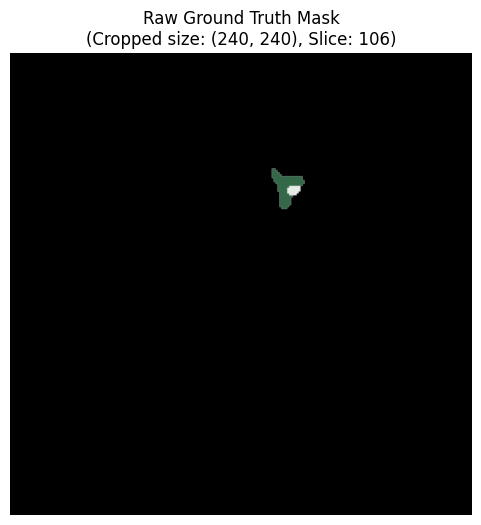

In [22]:
# ==========================================
# 7c. Quick View: Raw Ground Truth (No Overlay)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os

gt_path = os.path.join(patient_data_dir, "tumor segmentation", "P01_tumor_mask_fu4.nii.gz")

try:
    # טעינת המידע הגולמי של הרדיולוג
    gt_raw_data = nib.load(gt_path).get_fdata()
    
    # חיפוש אוטומטי של החתך שבו נמצא רוב הגידול
    tumor_pixels_per_slice = np.sum(gt_raw_data > 0, axis=(0, 1))
    best_gt_slice = int(np.argmax(tumor_pixels_per_slice))
    
    # שליפת החתך הרלוונטי וסיבוב שלו
    gt_s = np.rot90(gt_raw_data[:, :, best_gt_slice])
    
    # ציור
    plt.figure(figsize=(6, 6))
    plt.imshow(gt_s, cmap='gray')
    plt.imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.8)
    plt.title(f'Raw Ground Truth Mask\n(Cropped size: {gt_s.shape}, Slice: {best_gt_slice})')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"❌ Error loading raw GT: {e}")

In [25]:
# ==========================================
# 8a. Data Loading: Prior Scan (fu2 - May 2020)
# ==========================================
import os
import nibabel as nib
from nibabel.processing import resample_from_to
import numpy as np

print("⏳ Loading Follow-Up 2 (fu2) scan to verify model accuracy prior to treatment artifacts...")

# Paths
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.."))
v1_workspace = os.path.join(BASE_DIR, "ml", "exploration", "outputs", "04_nnunet_v1_workspace")
stripped_inputs_dir = os.path.join(v1_workspace, "nnUNet_stripped_inputs")
output_masks_dir = os.path.join(v1_workspace, "output_masks")
patient_data_dir = os.path.join(BASE_DIR, "data", "P01")

# Specific scan for May 2020 (fu2)
mri_path = os.path.join(stripped_inputs_dir, "P01_20200520_0000.nii.gz")
pred_path = os.path.join(output_masks_dir, "P01_20200520.nii.gz")
gt_path = os.path.join(patient_data_dir, "tumor segmentation", "P01_tumor_mask_fu2.nii.gz")

try:
    mri_img = nib.load(mri_path)
    pred_img = nib.load(pred_path)
    gt_img_raw = nib.load(gt_path)

    # ALIGNMENT FIX: Resample the cropped Ground Truth to match the MRI's exact dimensions
    gt_img_aligned = resample_from_to(gt_img_raw, mri_img, order=0)

    # Extract the data arrays into memory
    mri_data = mri_img.get_fdata()
    pred_data = pred_img.get_fdata()
    gt_data = gt_img_aligned.get_fdata()
    
    print("✅ fu2 Data loaded and aligned successfully! Proceed to 8b.")
    
except Exception as e:
    print(f"❌ An error occurred: {e}")

⏳ Loading Follow-Up 2 (fu2) scan to verify model accuracy prior to treatment artifacts...
✅ fu2 Data loaded and aligned successfully! Proceed to 8b.


In [ ]:
# ===================================================
# 8b. Interactive Slider: Prior Scan (fu2 - May 2020)
# ===================================================
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

if 'mri_data' in locals() and 'pred_data' in locals() and 'gt_data' in locals():
    
    # AUTO-LOCATE: Find the slice with the maximum tumor area in the prediction
    tumor_pixels_per_slice = np.sum(pred_data > 0, axis=(0, 1))
    best_slice = int(np.argmax(tumor_pixels_per_slice))
    
    print(f"🎯 Auto-detected maximum tumor volume at Slice (Z): {best_slice}")
    
    def plot_slice(z_slice):
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        mri_s = np.rot90(mri_data[:, :, z_slice])
        gt_s = np.rot90(gt_data[:, :, z_slice])
        pred_s = np.rot90(pred_data[:, :, z_slice])
        
        axes[0].imshow(mri_s, cmap='gray')
        axes[0].set_title(f'MRI (Slice {z_slice})')
        
        axes[1].imshow(mri_s, cmap='gray')
        axes[1].imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.7, vmin=0.1, vmax=1.0)
        axes[1].set_title('Ground Truth (Green)')
        
        axes[2].imshow(mri_s, cmap='gray')
        axes[2].imshow(np.ma.masked_where(pred_s <= 0, pred_s), cmap='Reds', alpha=0.7, vmin=0.1, vmax=1.0)
        axes[2].set_title('nnU-Net Prediction (Red)')
        
        axes[3].imshow(mri_s, cmap='gray')
        axes[3].imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.5, vmin=0.1, vmax=1.0)
        axes[3].imshow(np.ma.masked_where(pred_s <= 0, pred_s), cmap='Reds', alpha=0.5, vmin=0.1, vmax=1.0)
        axes[3].set_title('Overlay Comparison (GT vs Pred)')
        
        for ax in axes: ax.axis('off')
        plt.show()

    widgets.interact(plot_slice, z_slice=widgets.IntSlider(
        min=0, max=mri_data.shape[2]-1, value=best_slice, description='Slice (Z)'
    ))

else:
    print("⚠️ Data not found in memory. Please run Cell 8a first.")

🎯 Auto-detected maximum tumor volume at Slice (Z): 21


interactive(children=(IntSlider(value=21, description='Slice (Z)', max=33), Output()), _dom_classes=('widget-i…

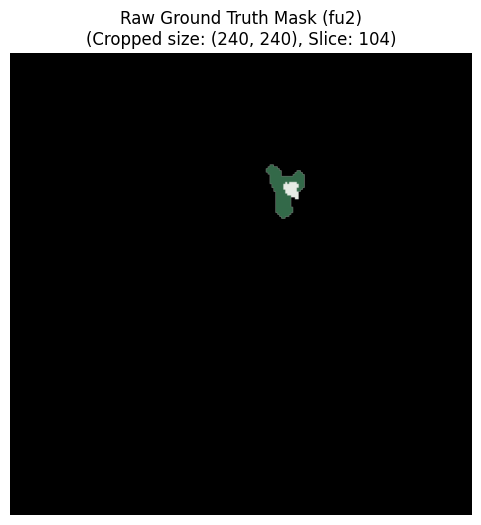

In [27]:
# ==========================================
# 8c. Quick View: Raw Ground Truth (fu2 - May 2020)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os

gt_path_fu2 = os.path.join(patient_data_dir, "tumor segmentation", "P01_tumor_mask_fu2.nii.gz")

try:
    # טעינת המידע הגולמי של הרדיולוג עבור fu2
    gt_raw_data = nib.load(gt_path_fu2).get_fdata()
    
    # חיפוש אוטומטי של החתך שבו נמצא רוב הגידול
    tumor_pixels_per_slice = np.sum(gt_raw_data > 0, axis=(0, 1))
    best_gt_slice = int(np.argmax(tumor_pixels_per_slice))
    
    # שליפת החתך הרלוונטי וסיבוב שלו
    gt_s = np.rot90(gt_raw_data[:, :, best_gt_slice])
    
    # ציור
    plt.figure(figsize=(6, 6))
    plt.imshow(gt_s, cmap='gray')
    plt.imshow(np.ma.masked_where(gt_s <= 0, gt_s), cmap='Greens', alpha=0.8)
    plt.title(f'Raw Ground Truth Mask (fu2)\n(Cropped size: {gt_s.shape}, Slice: {best_gt_slice})')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"❌ Error loading raw GT: {e}")

###  Clinical Insight: Analyzing `fu2` Discrepancies (False Positives & Over-segmentation)

By comparing the nnU-Net predictions across multiple slices with the radiologist's raw Ground Truth (GT) for the `fu2` (May 2020) scan, we identified a critical pattern in the model's behavior:

* **The True Positive (Accurate Detection):** In specific slices (e.g., Slice 10), the model successfully identified the actual tumor. The predicted shape—a unilateral lesion with a distinct necrotic core (the "hole" in the center)—perfectly matches the morphological structure labeled by the radiologist in the raw GT.
* **The False Positives (Symmetrical Artifacts):** In other areas (e.g., Slice 21), the model erroneously segmented large, perfectly symmetrical regions surrounding the brain's ventricles. Malignant brain tumors rarely grow in such a perfectly bilateral pattern.
* **The Ground Truth Confirmation:** The raw GT confirms that the radiologist only marked the single, unilateral mass. The secondary symmetrical regions were entirely ignored by the human expert.

####  Key Takeaway & Model Limitations
This visual investigation solves the mystery of the inflated volume predictions seen in our longitudinal graphs. It proves that while nnU-Net v1 is highly capable of detecting the true tumor mass, it struggles with **False Positives on contrast-enhanced T1c scans**. 

Because the network evaluates pixel intensity without high-level anatomical reasoning (such as recognizing bilateral symmetry), it mistakenly classifies natural White Matter Hyperintensities (WMHs), treatment-related edema, or radiation scars as active tumor tissue. This highlights the crucial need for human-in-the-loop verification when deploying standalone AI segmentation models in clinical oncology.